# SRA Learning & Routing Demo (Copy Task)

In this notebook, we train an SRA model on a simple task (Copy task: outputting the input sequence exactly).
We will visualize **how the 'routing' (which synapse each input token is assigned to) changes** before and after training, observing how SRA specializes and selectively uses experts (synapses) for the task.

## 1. 環境セットアップ
Execute the following cell if you are on Google Colab.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. Import Libraries and Prepare Model

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_experiment import make_batch, make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set up a slightly smaller model for faster training
config = MoESRAConfig(
    vocab_size=20,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=4,  # 4 experts (synapses)
    k=2,
    max_seq_len=32
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. Define Visualization Function
Prepare a function to display routing weights as a heatmap.

=== Before Training ===


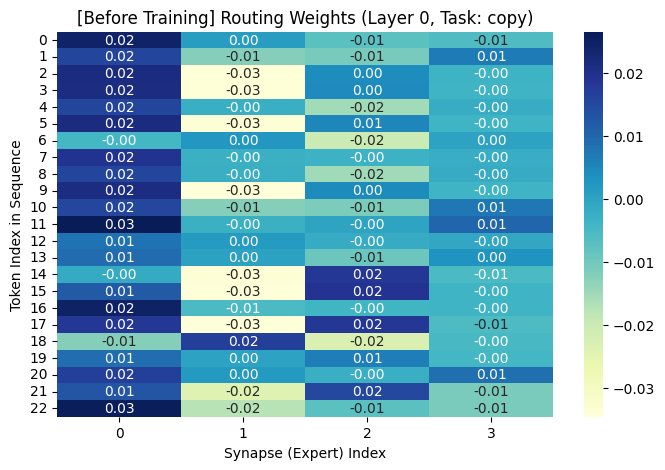

In [3]:
def visualize_routing(model, task="copy", title_prefix=""):
    model.eval()
    # Create a batch for evaluation (sequence length 10)
    x, y = make_batch(task, batch_size=1, min_len=10, max_len=10, device=device)
    
    with torch.no_grad():
        y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
        outputs, routing_weights, _ = model(x, y_in)
        
    # Get routing weights of the first layer
    layer_idx = 0
    weights = routing_weights[layer_idx][0].cpu().numpy()
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
    plt.title(f"{title_prefix} Routing Weights (Layer {layer_idx}, Task: {task})")
    plt.xlabel("Synapse (Expert) Index")
    plt.ylabel("Token Index in Sequence")
    plt.show()

# Visualize state before training
print("=== Before Training ===")
visualize_routing(model, title_prefix="[Before Training]")

## 4. Execute Training (Copy Task)
Train the 'Copy task' for a few epochs.

In [4]:
print("Training started...")
model.train()

epochs = 300
batch_size = 32

for epoch in range(epochs):
    x, y = make_batch("copy", batch_size, 5, 10, device)
    
    optimizer.zero_grad()
    y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
    # CrossEntropyLoss (match output shapes)
    # outputs: [batch, seq, vocab], y: [batch, seq]
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1))
    
    # Add router load balancing loss (to prevent overusing specific experts)
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | LB Loss: {lb_loss.item():.4f}")

print("Training finished!")

Training started...


Epoch 50/300 | Loss: 1.7347 | LB Loss: 0.0001


Epoch 100/300 | Loss: 0.0989 | LB Loss: 0.0001


Epoch 150/300 | Loss: 0.0005 | LB Loss: 0.0001


Epoch 200/300 | Loss: 0.0001 | LB Loss: 0.0000


Epoch 250/300 | Loss: 0.0000 | LB Loss: 0.0000


Epoch 300/300 | Loss: 0.0001 | LB Loss: 0.0000
Training finished!


## 5. Check Routing and Inference After Training
Check how routing (heatmap bias) has changed before and after training.
As training progresses, you should observe the router intentionally selecting specific experts (synapses), causing the weights to become biased (specialized).

=== After Training ===


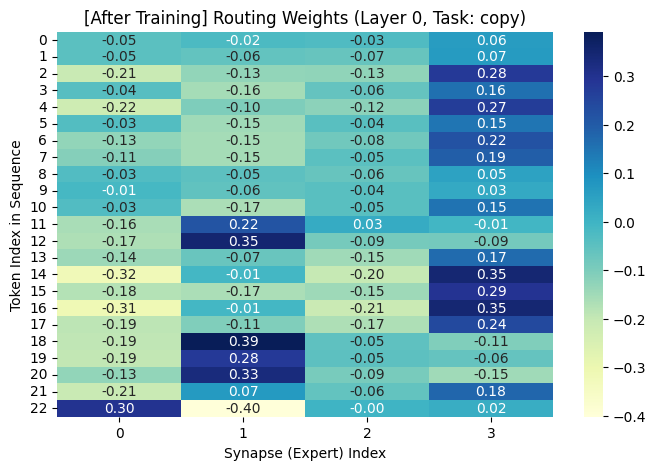


--- Inference Results ---
Input (Target) : [8, 13, 5, 9, 9, 8, 12, 12, 2]
Prediction     : [8, 13, 5, 9, 9, 8, 12, 12, 2]

=> Success! The model learned to copy.


In [5]:
print("=== After Training ===")
visualize_routing(model, title_prefix="[After Training]")

# Try inference to see if the task is actually solved
model.eval()
x, y = make_batch("copy", batch_size=1, min_len=8, max_len=8, device=device)
with torch.no_grad():
    outputs, _, _ = model(x, torch.zeros_like(y))
    preds = outputs.argmax(dim=-1)
    
print("\n--- Inference Results ---")
print(f"Input (Target) : {y[0].tolist()}")
print(f"Prediction     : {preds[0].tolist()}")
if y[0].tolist() == preds[0].tolist():
    print("\n=> Success! The model learned to copy.")
else:
    print("\n=> Failed... It might need a few more training steps (epochs).")